Audita exactamente estos bloques:

  - **Descubrimiento de archivos**: recorre el árbol `ticker=*/year=*/*.parquet` y construye manifiesto de archivos a validar.
  - **Contrato de esquema**: valida presencia de columnas requeridas (por ejemplo ticker, timestamp/date y campos OHLCV esperados).
  - **Tipos y parseo temporal**: comprueba que fechas/timestamps se puedan parsear y detecta nulos/valores inválidos.
  - **Calidad por archivo**: revisa filas vacías, duplicados, inconsistencias básicas de OHLCV y desalineaciones de fecha.
  - **Severidad de hallazgos**: clasifica eventos en niveles (hard/soft) y guarda causa detallada para cada incidencia.
  - **Cola de reintento**: genera `retry_queue_ohlcv_daily_current.csv` con archivos/tickers que deben reprocesarse.
  - **Estado en vivo de corrida**: escribe `live_status_ohlcv_daily.json` con progreso, conteos y resumen operativo.
  - **Cobertura esperada de universo**: si se define `EXPECTED_TICKERS_FILE`, compara tickers esperados vs observados en `DATA_ROOT` y
  reporta faltantes.
  - **Rescan/restart controlado**: soporta `RESET_STATE`, `RESCAN_ALL`, `DISCOVERY_MODE`, `MAX_FILES` y política de reintentos para
  auditoría incremental o completa.

  Artefactos principales que produce:

  - `ohlcv_daily_events_current.csv`: hallazgos detallados de auditoría.
  - `retry_queue_ohlcv_daily_current.csv`: pendientes de reproceso.
  - `live_status_ohlcv_daily.json`: estado consolidado de la ejecución.

In [6]:
# Jupyter cell: lanzar auditoría OHLCV daily estricta (full scan)
from pathlib import Path
import pandas as pd

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\044_agent_validate_ohlcv_daily_strict.py")
DATA_ROOT = Path(r"D:\ohlcv_daily")

RUN_ID = "20260309_ohlcv_daily_full_01"
RUN_BASE = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\ohlcv_daily_audit")
RUN_DIR = RUN_BASE / RUN_ID

MAX_FILES = 999999
RESET_STATE = True
RESCAN_ALL = True
DISCOVERY_MODE = "full"       # "fast" o "full"
RETRY_POLICY = "hard_only"    # "hard_only" o "hard_and_soft"
MAX_RETRY_ATTEMPTS = 3
MAX_TS_DATE_MISMATCH_PCT = 0.0
CLOSEABLE_SOFT_FAIL_CAUSES = set()

# cobertura esperada de tickers
EXPECTED_TICKERS_FILE = Path(
    r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\universe_pti\tickers_2005_2026_upper.parquet"
)

RUN_DIR.mkdir(parents=True, exist_ok=True)
exec(SCRIPT.read_text(encoding="utf-8"), globals(), globals())

print("\nArtifacts:")
print(RUN_DIR / "ohlcv_daily_events_current.csv")
print(RUN_DIR / "retry_queue_ohlcv_daily_current.csv")
print(RUN_DIR / "live_status_ohlcv_daily.json")

RUN_ID: 20260309_ohlcv_daily_full_01
DATA_ROOT: D:\ohlcv_daily
RUN_DIR: C:\TSIS_Data\v1\backtest_SmallCaps\runs\ohlcv_daily_audit\20260309_ohlcv_daily_full_01
discovery_mode: full
all_files_scanned: 125400 | candidates: 125400 | batch: 125400 | discovery_complete: True
RETRY_POLICY: hard_only | MAX_RETRY_ATTEMPTS: 3
MAX_TS_DATE_MISMATCH_PCT: 0.0
CLOSEABLE_SOFT_FAIL_CAUSES: []

Resumen por severidad (current):
 severity  count
     PASS 125372
SOFT_FAIL     28

Top 10 causas (issues+warns) en current:
cause_type                  cause  count
      warn high_zero_volume_ratio     28

Saved artifacts:
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\ohlcv_daily_audit\20260309_ohlcv_daily_session_01\run_config_ohlcv_daily.json
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\ohlcv_daily_audit\20260309_ohlcv_daily_session_01\ohlcv_daily_agent_state.json
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\ohlcv_daily_audit\20260309_ohlcv_daily_session_01\ohlcv_daily_events_history.csv
- C:\TSIS_Data\v1\backtest_Sma

RUN_DIR: C:\TSIS_Data\v1\backtest_SmallCaps\runs\ohlcv_daily_audit\20260309_ohlcv_daily_session_01

=== EXECUTIVE SUMMARY ===
overall  files_total  rows_total  tickers_total  years_total  pass_pct_files  fail_pct_files  soft_fail_pct_files  fail_pct_rows  fail_tickers  fail_years  hhi_fail_concentration  expected_total  observed_in_data_root  missing_in_data_root  retry_rows
     OK       125400    27415558          12203           22         99.9777          0.0223               0.0223         0.0207             5          18                 0.27551               0                      0                     0           0

=== CRITERIA (PASS/FAIL) ===
                 criterion  pass
            hard_fail_zero  True
soft_fail_pct_le_threshold  True
         retry_queue_empty  True
      expected_coverage_ok  True

=== SEVERITY DISTRIBUTION ===
 severity  files     rows  files_pct  rows_pct
     PASS 125372 27409884    99.9777   99.9793
SOFT_FAIL     28     5674     0.0223    0.0207

==

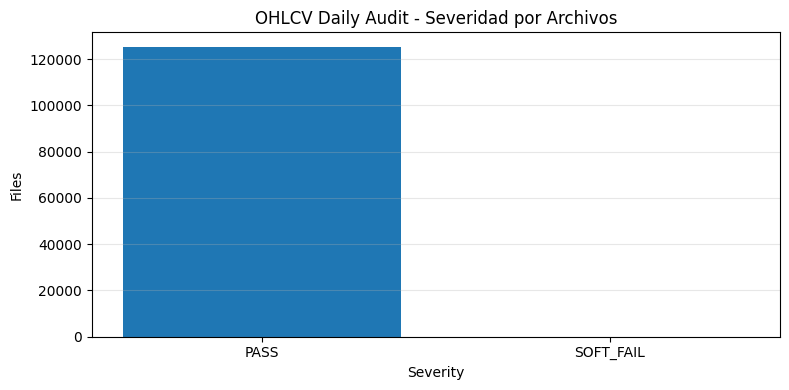

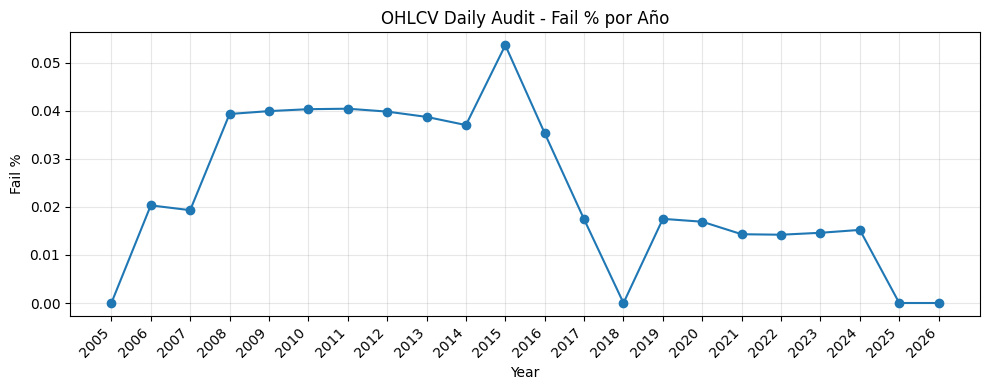

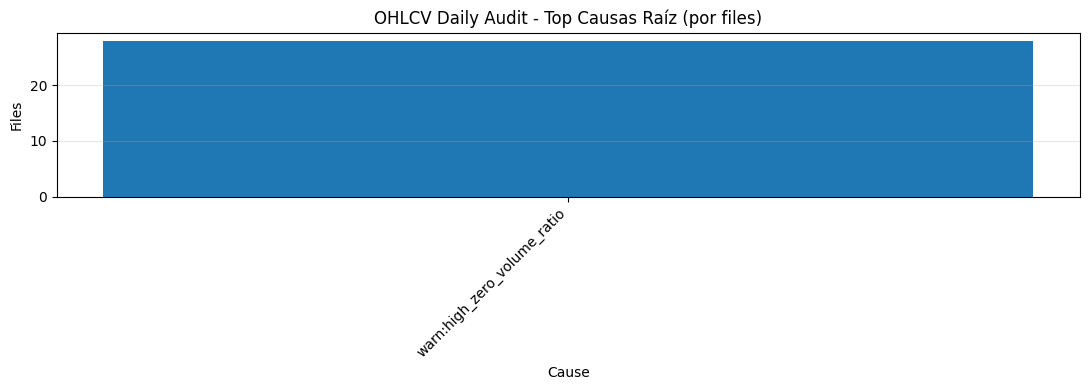

In [15]:


import runpy, sys

sys.argv = [
    "045_agent_validate_ohlcv_daily_report.py",
    "--run-dir",
    r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\ohlcv_daily_audit\20260309_ohlcv_daily_session_01",
]
_ = runpy.run_path(
    r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\045_agent_validate_ohlcv_daily_report.py",
    run_name="__main__",
)

Lectura rápida y exacta: la auditoría da OK real, con incidencias mínimas y concentradas.

  - overall=OK: no hay fallos duros ni cola pendiente.
  - files_total=125400: se auditaron 125,400 parquet diarios (ticker-año).
  - rows_total=27,415,558: volumen total inspeccionado.
  - pass_pct_files=99.9777%: casi todo pasa.
  - soft_fail_pct_files=0.0223% (28 archivos): incidencias leves.
  - fail_pct_rows=0.0207%: el impacto en datos es muy bajo.
  - fail_tickers=5, fail_years=18: los problemas están muy localizados.

  Criterios

  - hard_fail_zero=True: ningún error crítico.
  - soft_fail_pct_le_threshold=True: los soft fail están bajo umbral.
  - retry_queue_empty=True: no hay nada para reprocesar.
  - expected_coverage_ok=True: cobertura esperada OK (en este run no venía baseline esperado en live_status, por eso sale 0/0/0).

  Distribución

  - PASS: 125,372 archivos.
  - SOFT_FAIL: 28 archivos.
  - ACTION REVIEW: solo esos 28.

  Causa raíz

  - Única causa: high_zero_volume_ratio (warn), en 28 archivos, 5 tickers. 
    - high_zero_volume_ratio: ratio alto de velas diarias sin volumen.
  - No hay mezcla de causas ni errores de esquema/fechas.

  Dónde están los soft fail

  - ASTI (10 años), TOPS (9), SONG (5), RNVA (3), MULN (1).
  - hhi_fail_concentration=0.2755: concentración moderada, no disperso por todo el universo.

  Temporal

  - Peor año relativo: 2015 con 0.0536% fail files.
  - 2005, 2018, 2025, 2026: 0 fails.
  - El patrón es estable y bajo en todo el rango.

  Conclusión operativa:

  - Puedes continuar pipeline con este dataset daily.
  - Lo único a vigilar: esos 5 tickers con volumen cero alto (posible micro-liquidez/OTC-like behavior histórico).

In [ ]:
from pathlib import Path

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\plot_ohlcv_daily_sessions.py")

for var in ["PARQUET_PATH", "TICKER", "YEAR", "MONTH"]:
    if var in globals():
        del globals()[var]

DATA_ROOT = Path(r"D:\ohlcv_daily")
CHART_STYLE = "candlestick"
SHOW_VOLUME = True
SHOW_VWAP = False

exec(SCRIPT.read_text(encoding="utf-8"), globals(), globals())

#Si luego quieres, le añado un toggle:
#- VIEW_MODE = "month" para velas
#- VIEW_MODE = "year" para línea anual limpia

Output()

Output()